In [ ]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 56.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import segmentation_models_pytorch as smp

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from tqdm.auto import tqdm

In [16]:
## mount google drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
## confuguration
IMAGE_DIR = "/content/drive/MyDrive/dataset/images"

MASK_DIR = "/content/drive/MyDrive/dataset/masks"

IMAGE_SIZE = 256

BATCH_SIZE = 8

EPOCHS = 50

LEARNING_RATE = 1e-4

TRAIN_RATIO = 0.70

VAL_RATIO = 0.15

TEST_RATIO = 0.15

SEED = 42

NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)


Device : cuda


In [20]:
## Set Random Seed
random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

In [21]:
## Albumentations
train_transform = A.Compose([

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.Rotate(limit=30, p=0.5),

    A.RandomBrightnessContrast(p=0.2),

    A.Normalize(

        mean=(0.485,0.456,0.406),

        std=(0.229,0.224,0.225)

    ),

    ToTensorV2()

])



val_transform = A.Compose([

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(

        mean=(0.485,0.456,0.406),

        std=(0.229,0.224,0.225)

    ),

    ToTensorV2()

])


In [22]:
## Dataset Class
class EBHIDataset(Dataset):

    def __init__(self,image_dir,mask_dir,transform=None):

        self.image_dir=image_dir

        self.mask_dir=mask_dir

        self.transform=transform

        self.images=sorted(os.listdir(image_dir))

    def __len__(self):

        return len(self.images)

    def __getitem__(self,index):

        image_name=self.images[index]

        image_path=os.path.join(self.image_dir,image_name)

        mask_path=os.path.join(self.mask_dir,image_name)

        image=cv2.imread(image_path)

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

        if self.transform:

            augmented=self.transform(image=image,mask=mask)

            image=augmented["image"]

            mask=augmented["mask"]

        mask=mask.float()/255.0

        mask=mask.unsqueeze(0)

        return image,mask

In [23]:
## Train / Validation / Test Split
dataset = EBHIDataset(

    IMAGE_DIR,

    MASK_DIR,

    transform=None

)

train_size = int(TRAIN_RATIO * len(dataset))

val_size = int(VAL_RATIO * len(dataset))

test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(

    dataset,

    [train_size, val_size, test_size],

    generator=torch.Generator().manual_seed(SEED)

)

print("Total :", len(dataset))

print("Train :", len(train_dataset))

print("Validation :", len(val_dataset))

print("Test :", len(test_dataset))


Total : 2226
Train : 1558
Validation : 333
Test : 335


In [24]:
## Apply Transform
train_data = EBHIDataset(

    IMAGE_DIR,

    MASK_DIR,

    transform=train_transform

)

val_data = EBHIDataset(

    IMAGE_DIR,

    MASK_DIR,

    transform=val_transform

)

test_data = EBHIDataset(

    IMAGE_DIR,

    MASK_DIR,

    transform=val_transform

)

train_data = torch.utils.data.Subset(train_data,train_dataset.indices)

val_data = torch.utils.data.Subset(val_data,val_dataset.indices)

test_data = torch.utils.data.Subset(test_data,test_dataset.indices)


Train Batches : 195
Validation Batches : 42
Test Batches : 42


torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])


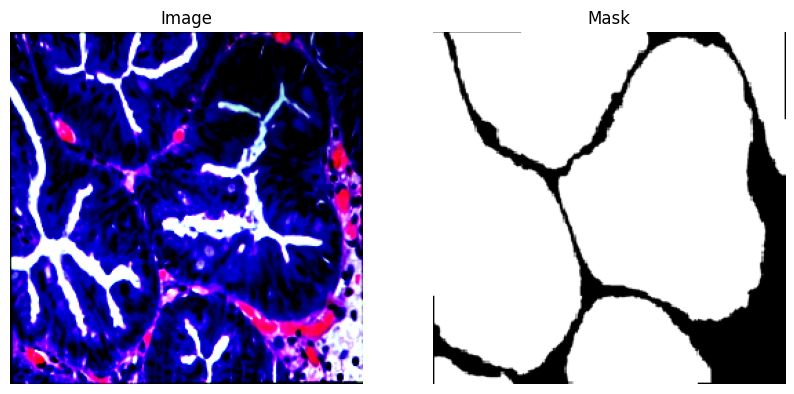

In [25]:
## Create DataLoader & Verify
train_loader = DataLoader(

    train_data,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

val_loader = DataLoader(

    val_data,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

test_loader = DataLoader(

    test_data,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

print("Train Batches :", len(train_loader))

print("Validation Batches :", len(val_loader))

print("Test Batches :", len(test_loader))

images,masks=next(iter(train_loader))

print(images.shape)

print(masks.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[0].permute(1,2,0).numpy())
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[0].squeeze(),cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [ ]:
!pip install -U segmentation-models-pytorch

In [26]:
import segmentation_models_pytorch as smp

print(smp.__version__)

0.5.0


In [27]:
## Create U-Net
model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1,

    activation=None

)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [28]:
## Move model to GPU
model = model.to(DEVICE)

print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [29]:
## Count Parameters
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print("Total Parameters :", total_params)

print("Trainable Parameters :", trainable_params)

Total Parameters : 24436369
Trainable Parameters : 24436369


In [30]:
## Test Forward Pass
images, masks = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print("Input Shape :", images.shape)

print("Output Shape :", outputs.shape)

Input Shape : torch.Size([8, 3, 256, 256])
Output Shape : torch.Size([8, 1, 256, 256])


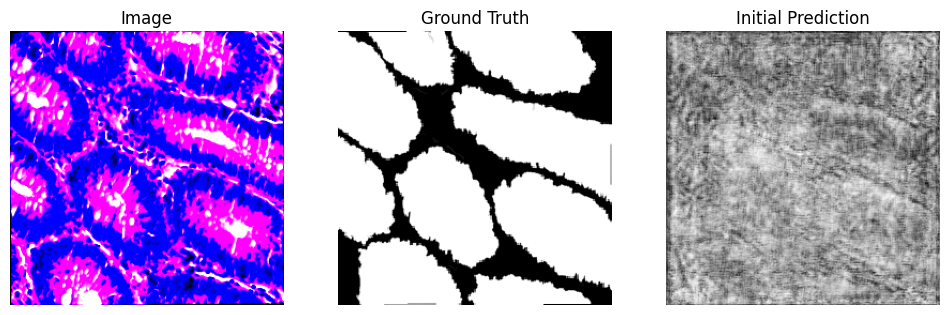

In [31]:
## Visualize Output
model.eval()

images, masks = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

pred = torch.sigmoid(outputs)

pred = pred.cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)

plt.imshow(images[0].cpu().permute(1,2,0))

plt.title("Image")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(masks[0].squeeze(),cmap="gray")

plt.title("Ground Truth")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(pred[0][0],cmap="gray")

plt.title("Initial Prediction")

plt.axis("off")

plt.show()

In [ ]:
!pip install torchinfo

In [32]:
## Save Model Summary
from torchinfo import summary

summary(

    model,

    input_size=(8,3,256,256)

)

Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [8, 1, 256, 256]          --
├─ResNetEncoder: 1-1                          [8, 3, 256, 256]          --
│    └─Conv2d: 2-1                            [8, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                       [8, 64, 128, 128]         128
│    └─ReLU: 2-3                              [8, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                         [8, 64, 64, 64]           --
│    └─Sequential: 2-5                        [8, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                   [8, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                   [8, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-3                   [8, 64, 64, 64]           73,984
│    └─Sequential: 2-6                        [8, 128, 32, 32]          --
│    │    └─BasicBlock: 3-4                   [8, 128, 32, 32]          230,144

In [ ]:
## Dice Loss
class DiceLoss(nn.Module):

    def __init__(self, smooth=1):

        super(DiceLoss, self).__init__()

        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)

        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (2.0 * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [ ]:
## Combined BCE + Dice Loss
bce_loss = nn.BCEWithLogitsLoss()

dice_loss = DiceLoss()

def combined_loss(predictions, targets):

    bce = bce_loss(predictions, targets)

    dice = dice_loss(predictions, targets)

    return bce + dice


In [38]:
## Pixel Accuracy
def pixel_accuracy(preds, masks):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    correct = (preds == masks).float().sum()

    total = torch.numel(preds)

    return correct / total

In [39]:
## Dice Score
def dice_score(preds, masks, smooth=1):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)

    masks = masks.view(-1)

    intersection = (preds * masks).sum()

    dice = (2 * intersection + smooth) / (
        preds.sum() + masks.sum() + smooth
    )

    return dice

In [40]:
## IoU Score
def iou_score(preds, masks, smooth=1):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)

    masks = masks.view(-1)

    intersection = (preds * masks).sum()

    union = preds.sum() + masks.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou

In [41]:
## Precision
def precision(preds, masks):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.cpu().numpy().flatten()

    masks = masks.cpu().numpy().flatten()

    return precision_score(
        masks,
        preds,
        zero_division=0
    )

In [42]:
## Recall
def recall(preds, masks):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.cpu().numpy().flatten()

    masks = masks.cpu().numpy().flatten()

    return recall_score(
        masks,
        preds,
        zero_division=0
    )

In [43]:
## F1 Score
def f1(preds, masks):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.cpu().numpy().flatten()

    masks = masks.cpu().numpy().flatten()

    return f1_score(
        masks,
        preds,
        zero_division=0
    )

In [ ]:
## Optimizer
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-4

)

In [ ]:
## Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=3

)

In [53]:
## Initialize Training Variables
best_dice = 0.0

patience = 7

counter = 0

train_losses = []

val_losses = []

train_dice_scores = []

val_dice_scores = []

train_iou_scores = []

val_iou_scores = []

In [ ]:
## Training Function
def train_one_epoch(model, loader, optimizer):

    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    loop = tqdm(loader, leave=True)

    for images, masks in loop:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_dice += dice_score(outputs, masks).item()

        running_iou += iou_score(outputs, masks).item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)

    epoch_dice = running_dice / len(loader)

    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [ ]:
## Validation Function
def validate(model, loader):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = combined_loss(outputs, masks)

            running_loss += loss.item()

            running_dice += dice_score(outputs, masks).item()

            running_iou += iou_score(outputs, masks).item()

    epoch_loss = running_loss / len(loader)

    epoch_dice = running_dice / len(loader)

    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [ ]:
## Training Loop
for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_dice, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    val_loss, val_dice, val_iou = validate(
        model,
        val_loader
    )

    scheduler.step(val_dice)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_dice_scores.append(train_dice)
    val_dice_scores.append(val_dice)

    train_iou_scores.append(train_iou)
    val_iou_scores.append(val_iou)

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f}")

    print(f"Validation Dice : {val_dice:.4f}")

    print(f"Train IoU : {train_iou:.4f}")

    print(f"Validation IoU : {val_iou:.4f}")

    if val_dice > best_dice:

        best_dice = val_dice

        counter = 0

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/best_segmentation_model.pth"
        )

        print("✅ Best Model Saved")

    else:

        counter += 1

        print(f"No Improvement ({counter}/{patience})")

    if counter >= patience:

        print("\n🛑 Early Stopping Activated")

        break


Epoch [1/50]


  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss : 0.5429
Validation Loss : 0.3298
Train Dice : 0.8803
Validation Dice : 0.9357
Train IoU : 0.7929
Validation IoU : 0.8796
✅ Best Model Saved

Epoch [2/50]


  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss : 0.3253
Validation Loss : 0.2999
Train Dice : 0.9317
Validation Dice : 0.9375
Train IoU : 0.8726
Validation IoU : 0.8829
✅ Best Model Saved

Epoch [3/50]


...

Train Loss : 0.1453
Validation Loss : 0.2391
Train Dice : 0.9672
Validation Dice : 0.9517
Train IoU : 0.9365
Validation IoU : 0.9082
No Improvement (5/7)

Epoch [43/50]


  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss : 0.1461
Validation Loss : 0.2356
Train Dice : 0.9670
Validation Dice : 0.9521
Train IoU : 0.9361
Validation IoU : 0.9088
No Improvement (6/7)

Epoch [44/50]


  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss : 0.1442
Validation Loss : 0.2392
Train Dice : 0.9673
Validation Dice : 0.9520
Train IoU : 0.9368
Validation IoU : 0.9086
No Improvement (7/7)

🛑 Early Stopping Activated


In [ ]:
## Load Best Model
model.load_state_dict(

    torch.load(

        "/content/drive/MyDrive/best_segmentation_model.pth",

        map_location=DEVICE

    )

)

model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


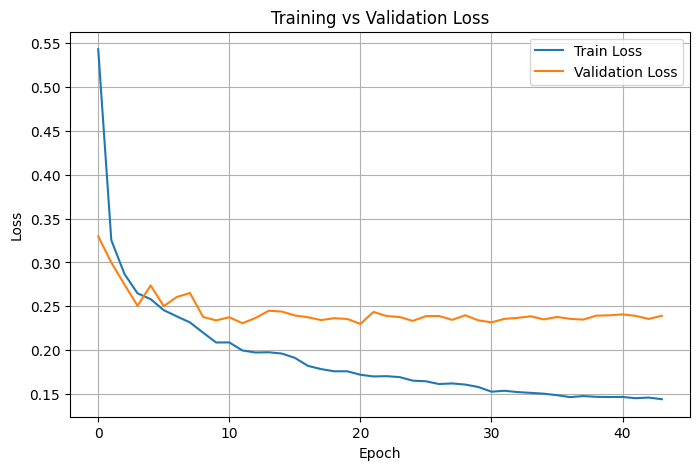

In [ ]:
## Plot Loss Curve
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train Loss")

plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

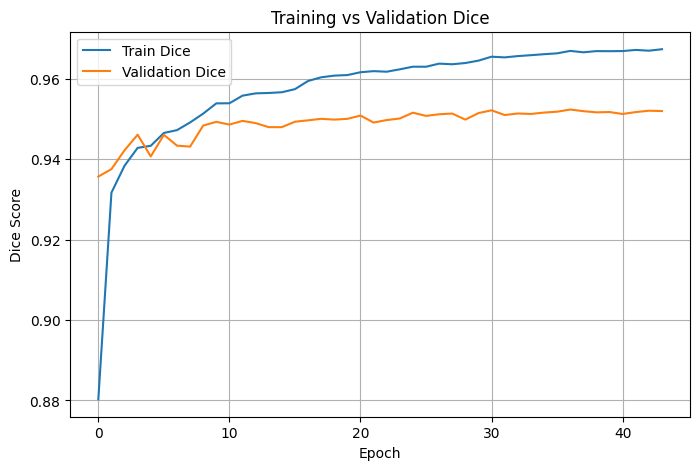

In [ ]:
## Plot Dice Score
plt.figure(figsize=(8,5))

plt.plot(train_dice_scores,label="Train Dice")

plt.plot(val_dice_scores,label="Validation Dice")

plt.xlabel("Epoch")

plt.ylabel("Dice Score")

plt.title("Training vs Validation Dice")

plt.legend()

plt.grid(True)

plt.show()

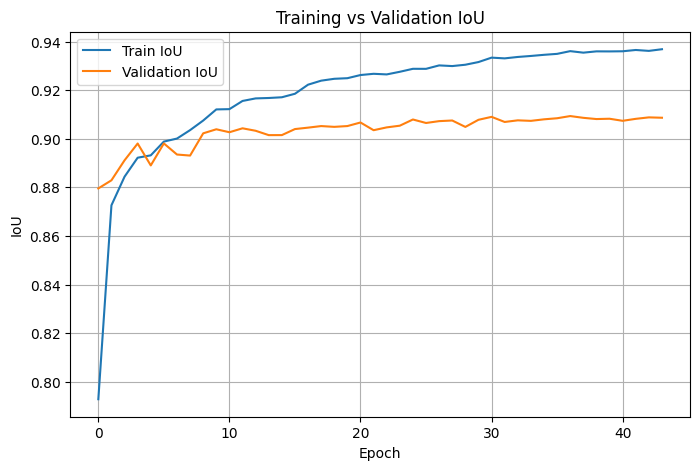

In [ ]:
## Plot IoU Score
plt.figure(figsize=(8,5))

plt.plot(train_iou_scores,label="Train IoU")

plt.plot(val_iou_scores,label="Validation IoU")

plt.xlabel("Epoch")

plt.ylabel("IoU")

plt.title("Training vs Validation IoU")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
## Verify Saved Model
import os

model_path = "/content/drive/MyDrive/best_segmentation_model.pth"

if os.path.exists(model_path):

    print("✅ Model Saved Successfully")

    print(model_path)

else:

    print("❌ Model Not Found")

❌ Model Not Found


In [33]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_dice": best_dice
}, "/content/drive/MyDrive/best_segmentation_model.pth")

NameError: name 'epoch' is not defined

In [34]:
import torch
## Load Best Model
checkpoint = torch.load(
    "/content/drive/MyDrive/best_segmentation_model.pth",
    map_location=DEVICE
)

# If you saved only state_dict
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE)
model.eval()

print("✅ Best Segmentation Model Loaded Successfully")

✅ Best Segmentation Model Loaded Successfully


In [46]:
## Test Function
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(model, loader):

    model.eval()

    pixel_acc = []
    dice = []
    iou = []
    precision = []
    recall = []
    f1 = []

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            pixel_acc.append(pixel_accuracy(outputs, masks).item())
            dice.append(dice_score(outputs, masks).item())
            iou.append(iou_score(outputs, masks).item())

            # Flatten before sklearn metrics
            y_true = masks.cpu().numpy().astype(np.uint8).flatten()
            y_pred = preds.cpu().numpy().astype(np.uint8).flatten()

            precision.append(
                precision_score(y_true, y_pred, zero_division=0)
            )

            recall.append(
                recall_score(y_true, y_pred, zero_division=0)
            )

            f1.append(
                f1_score(y_true, y_pred, zero_division=0)
            )

    return {

        "Pixel Accuracy": np.mean(pixel_acc),

        "Dice Score": np.mean(dice),

        "IoU Score": np.mean(iou),

        "Precision": np.mean(precision),

        "Recall": np.mean(recall),

        "F1 Score": np.mean(f1)

    }

In [47]:
## Evaluate on Test Set
results = evaluate_model(model, test_loader)

print("\n========== FINAL TEST RESULTS ==========\n")

for key, value in results.items():

    print(f"{key} : {value:.4f}")

  0%|          | 0/42 [00:00<?, ?it/s]


========== FINAL TEST RESULTS ==========

Pixel Accuracy : 0.8480
Dice Score : 0.9506
IoU Score : 0.9062
Precision : 0.8288
Recall : 0.9700
F1 Score : 0.8901


In [48]:
## display prediction
model.eval()

images, masks = next(iter(test_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

preds = torch.sigmoid(outputs)

preds = (preds > 0.5).float()

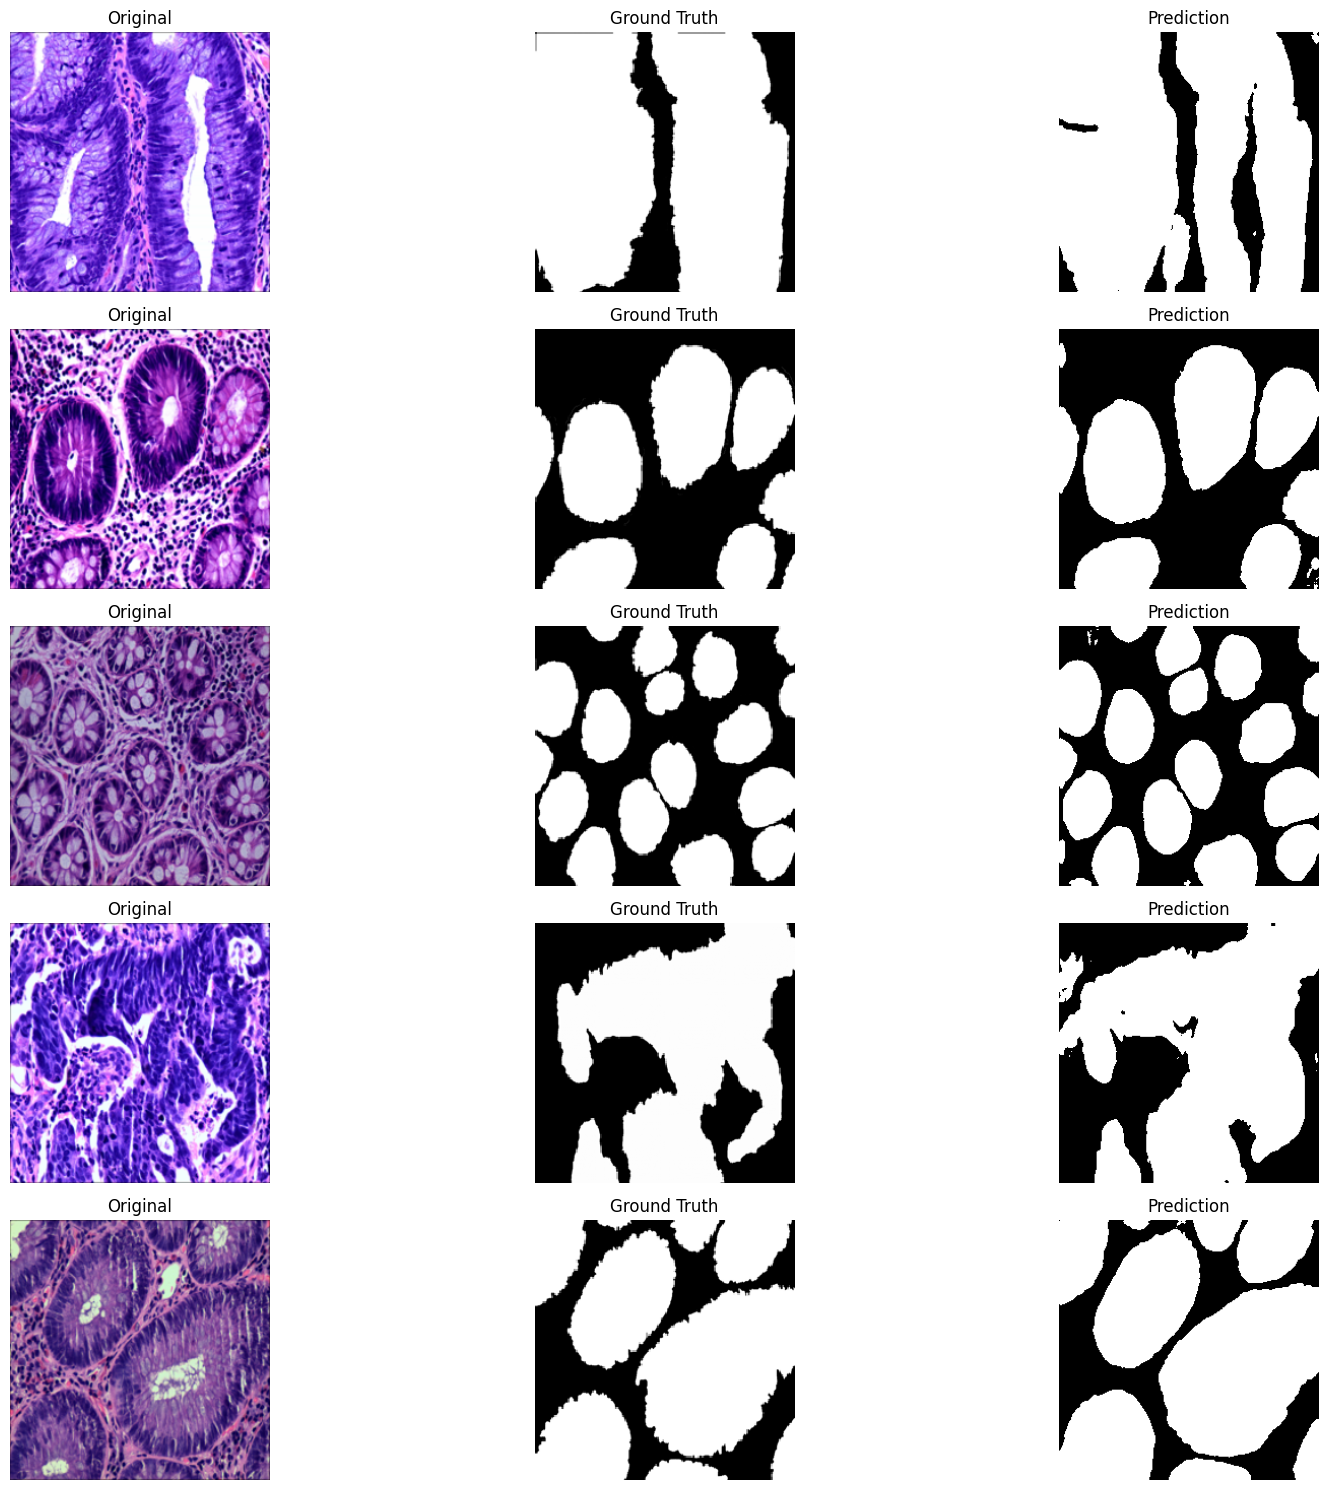

In [49]:
## Show 5 Predictions
plt.figure(figsize=(18,15))

for i in range(5):

    image = images[i].cpu().permute(1,2,0).numpy()

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    image = image * std + mean
    image = np.clip(image,0,1)

    true_mask = masks[i].cpu().squeeze()

    pred_mask = preds[i].cpu().squeeze()

    plt.subplot(5,3,3*i+1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(5,3,3*i+2)
    plt.imshow(true_mask,cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5,3,3*i+3)
    plt.imshow(pred_mask,cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()

plt.show()

In [50]:
## Save Sample Prediction
sample_prediction = preds[0].cpu().numpy().squeeze()

plt.imsave(
    "/content/drive/MyDrive/sample_prediction.png",
    sample_prediction,
    cmap="gray"
)

print("✅ Sample Prediction Saved")

✅ Sample Prediction Saved


In [51]:
## Save Final Model
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/final_segmentation_model.pth"
)

print("✅ Final Model Saved")

✅ Final Model Saved


In [54]:
## Save Training Metrics
import pandas as pd

history = pd.DataFrame({

    "Train Loss": train_losses,

    "Validation Loss": val_losses,

    "Train Dice": train_dice_scores,

    "Validation Dice": val_dice_scores,

    "Train IoU": train_iou_scores,

    "Validation IoU": val_iou_scores

})

history.to_csv(

    "/content/drive/MyDrive/training_history.csv",

    index=False

)

print("✅ Training History Saved")

✅ Training History Saved


In [55]:
## Final Summary
print("="*50)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*50)

print("Dataset :", len(dataset))

print("Train Images :", len(train_data))

print("Validation Images :", len(val_data))

print("Test Images :", len(test_data))

print()

for key,value in results.items():

    print(f"{key} : {value:.4f}")

print()

print("Model Saved Successfully")

print("Training History Saved")

print("Prediction Images Saved")

print("="*50)

PROJECT COMPLETED SUCCESSFULLY
Dataset : 2226
Train Images : 1558
Validation Images : 333
Test Images : 335

Pixel Accuracy : 0.8480
Dice Score : 0.9506
IoU Score : 0.9062
Precision : 0.8288
Recall : 0.9700
F1 Score : 0.8901

Model Saved Successfully
Training History Saved
Prediction Images Saved
